*   Name:Sam George





# **Conditional Variational Autoencoder (CVAE)**

**Part 1: Data Preparation and Exploration**

In [7]:
# imports and data loaders
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# Transform: Normalize images to [0,1]
transform = transforms.Compose([transforms.ToTensor()])

# Datasets
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split validation
train_data, val_data = torch.utils.data.random_split(train_dataset, [50000, 10000])

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

def show_grid(images, nrow=8):
    grid = np.transpose(utils.make_grid(images, nrow=nrow).numpy(), (1,2,0))
    plt.figure(figsize=(10,2))
    plt.imshow(grid.squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()


* Imports PyTorch, dataset utilities, DataLoader, optimization modules, and plotting tools.
* Uses a simple transform `ToTensor()` to convert images into tensors with pixel values in **[0, 1]**.
* Loads MNIST dataset:

  * `train_dataset`: 60K training images of digits (0–9)
  * `test_dataset`: 10K testing images
* Splits training data into:

  * **50K for training**
  * **10K for validation**
* Creates DataLoaders for batching and efficient iteration:

  * `shuffle=True` only for training (for randomness during learning)
  * `num_workers=2` for faster loading
* Defines a helper function `show_grid()` to visualize sample images in a grid using Matplotlib.

In [8]:
#  helpers and hyperparams
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

latent_dim = 20
num_classes = 10
img_dim = 28 * 28
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

save_dir = "/content/drive/MyDrive/cvae_mnist"  # change or use /content/
os.makedirs(save_dir, exist_ok=True)
print("Device:", device)


Device: cpu


* **One-Hot Encoding Function**

  * Converts digit labels (0–9) into one-hot vectors (shape: `[batch, 10]`)
  * Needed for **Conditional VAE (CVAE)** conditioning labels along with images

* **Hyperparameters**

  * `latent_dim = 20`: Size of latent representation
  * `num_classes = 10`: Digits 0–9 (MNIST)
  * `img_dim = 28×28`: Flattened image dimension

* **Device Setup**

  * Uses **GPU if available**, else CPU

* **Save Directory**

  * Creates folder for model checkpoints and outputs

* **Print Device**

  * Shows whether the model will run on GPU or CPU


**Part 2: CVAE Model Implementation**

In [9]:
# CVAE model
class Encoder(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(img_dim + num_classes, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x, y):
        x = x.view(x.size(0), -1)
        x = torch.cat([x, y], dim=1)
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        mu = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        return mu, log_var

def reparameterize(mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

class Decoder(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim + num_classes, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc_out = nn.Linear(512, img_dim)

    def forward(self, z, y):
        z = torch.cat([z, y], dim=1)
        h = F.relu(self.fc1(z))
        h = F.relu(self.fc2(h))
        x_recon = torch.sigmoid(self.fc_out(h))
        x_recon = x_recon.view(-1, 1, 28, 28)
        return x_recon

class CVAE(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super(CVAE, self).__init__()
        self.encoder = Encoder(latent_dim, num_classes)
        self.decoder = Decoder(latent_dim, num_classes)

    def forward(self, x, y):
        mu, log_var = self.encoder(x, y)
        z = reparameterize(mu, log_var)
        recon = self.decoder(z, y)
        return recon, mu, log_var


### Conditional VAE Model

* **Encoder**

  * Takes **input image + label** (one-hot vector)
  * Fully connected layers extract features
  * Outputs **mu** (mean) and **log_var** (log variance) for latent distribution

* **Reparameterization Trick**

  * Samples latent vector `z` using:

    ```
    z = mu + std * random_noise
    ```
  * Allows gradient flow through sampling step

* **Decoder**

  * Takes **latent vector + label** as input
  * Reconstructs a **28×28 grayscale** image
  * Uses sigmoid to constrain output pixels to `[0,1]`

* **CVAE Class**

  * Combines encoder + decoder
  * Forward pass returns:

    * Reconstructed images
    * `mu` & `log_var` for KL divergence loss

### Why this is Conditional VAE (CVAE)?

* Model conditions both **encoding and decoding** on class labels
* Allows generation of images for **specific digits** (e.g., always generate "7")

In [10]:
# setup model, optimizer, loss
model = CVAE(latent_dim, num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def cvae_loss(recon_x, x, mu, log_var, reduction='sum'):
    # default per-batch sum; we'll divide by dataset size when printing
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction=reduction)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_loss


* **Model Initialization**

  * Creates CVAE with:

    * `latent_dim = 20`
    * `num_classes = 10`
  * Moves model to GPU if available

* **Optimizer**

  * Adam optimizer with learning rate `1e-3`
  * Handles automatic parameter updates during training

* **CVAE Loss Function**

  * Total loss = **Reconstruction Loss + KL Divergence**
  * `binary_cross_entropy` checks how close reconstructed image is to original
  * KL term pushes latent space toward a **normal distribution**
  * Loss is summed over the batch (normalized later for logs)

**Part 3: Loss Function and Training**

In [6]:
# training loop with validation & saving best model
epochs = 10
best_val = float('inf')

for epoch in range(1, epochs+1):
    model.train()
    train_loss = 0.0
    for x, labels in train_loader:
        x = x.to(device)
        labels = labels.to(device)
        y = one_hot(labels, num_classes).to(device)

        optimizer.zero_grad()
        recon, mu, log_var = model(x, y)
        loss = cvae_loss(recon, x, mu, log_var)   # sum over batch
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader.dataset)  # per-sample average

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_val, labels_val in val_loader:
            x_val = x_val.to(device)
            labels_val = labels_val.to(device)
            y_val = one_hot(labels_val, num_classes).to(device)
            recon_val, mu_val, log_var_val = model(x_val, y_val)
            loss_val = cvae_loss(recon_val, x_val, mu_val, log_var_val)
            val_loss += loss_val.item()
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch:02d}  Train loss: {train_loss:.6f}  Val loss: {val_loss:.6f}")

    # Save checkpoint
    torch.save({'epoch': epoch, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict()},
               os.path.join(save_dir, f'cvae_epoch{epoch}.pth'))
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), os.path.join(save_dir, 'cvae_best.pth'))


Epoch 01  Train loss: 175.459515  Val loss: 138.297277
Epoch 02  Train loss: 127.472257  Val loss: 119.521414
Epoch 03  Train loss: 115.547054  Val loss: 111.783931
Epoch 04  Train loss: 109.802333  Val loss: 107.322627
Epoch 05  Train loss: 106.606005  Val loss: 105.432832
Epoch 06  Train loss: 104.450916  Val loss: 103.666890
Epoch 07  Train loss: 102.941224  Val loss: 102.563862
Epoch 08  Train loss: 101.727778  Val loss: 101.620275
Epoch 09  Train loss: 100.754769  Val loss: 100.978578
Epoch 10  Train loss: 99.949060  Val loss: 100.176905


* Runs training for **10 epochs**

* **Training Phase**

  * Converts labels to **one-hot**
  * Forward pass → compute loss
  * Backpropagation + optimizer update
  * Tracks average training loss

* **Validation Phase**

  * Model in `eval()` mode (no gradient update)
  * Computes validation loss for comparison/improvement

* **Loss Normalization**

  * Total loss divided by dataset size → per-sample loss

* **Checkpoint Saving**

  * Saves model and optimizer at each epoch
  * Overwrites **best model** when validation loss improves

* **Printed Output**

  * Shows training + validation loss every epoch → monitoring learning quality


**Part 4: Conditional Generation and Evaluation**

In [11]:
# reconstruction helper & conditional generation
model.eval()

def show_reconstructions(model, data_loader, n=8):
    imgs, labs = next(iter(data_loader))
    imgs = imgs[:n].to(device)
    labs = labs[:n].to(device)
    y = one_hot(labs, num_classes).to(device)
    with torch.no_grad():
        recon, _, _ = model(imgs, y)
    combined = torch.cat([imgs.cpu(), recon.cpu()])
    show_grid(combined, nrow=n)  # first row originals, second row reconstructions

def generate_conditioned_images(model, label_tensor, n=10):
    """
    label_tensor: a 1D tensor of labels you want to sample for (e.g. torch.tensor([3]) or torch.arange(10))
    n: number of images to generate in total
    If label_tensor has length >1, it will generate n images by cycling across labels in label_tensor.
    """
    model.eval()
    with torch.no_grad():
        labels = label_tensor.cpu().numpy().tolist()
        # prepare y of shape (n, num_classes) by cycling labels
        chosen = [labels[i % len(labels)] for i in range(n)]
        y = one_hot(torch.tensor(chosen, dtype=torch.long), num_classes).to(device)
        z = torch.randn(n, latent_dim).to(device)
        generated = model.decoder(z, y).cpu()

    plt.figure(figsize=(n/2,2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(generated[i][0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Generated conditioned on labels: {labels}")
    plt.show()


### Reconstruction Helper — `show_reconstructions()`

* Takes a batch from the data loader
* Uses the same labels to condition the CVAE
* Shows:

  * **Top row** → original images
  * **Bottom row** → reconstructed images
* Helps visualize how well the model learned to reproduce input digits

### Conditional Image Generation — `generate_conditioned_images()`

* Allows generation of **new digits** by specifying a label

  * Example: generate all "3"s → `torch.tensor([3])`
  * Example: generate digits 0–9 → `torch.arange(10)`
* Cycles through labels if multiple are provided
* Random latent vectors `z` → new samples conditioned on labels
* Displays the results in a single row

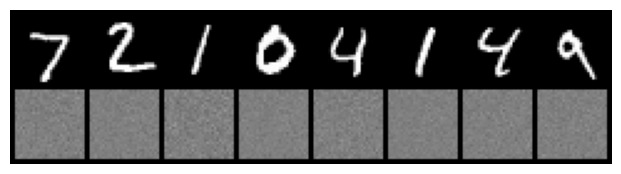

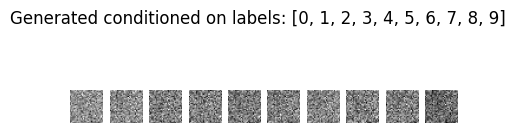

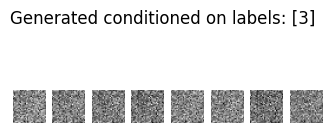

In [12]:
# visualize and generation
# reconstructions (originals top row, recon bottom row)
show_reconstructions(model, test_loader, n=8)

# Generate 10 images cycling labels 0..9 (one per label)
generate_conditioned_images(model, torch.arange(0,10), n=10)

# Example: generate 8 examples conditioned on label '3'
generate_conditioned_images(model, torch.tensor([3]), n=8)


### Reconstruction Visualization

* Shows how well the model can **recreate input images**
* **Top row** → true test images
* **Bottom row** → CVAE reconstructions
* Good reconstructions = model learned meaningful latent features

### Conditional Generation (Digits 0–9)

* Generates **new** images using random latent vectors `z`
* Conditions decoder using one-hot labels 0→9
* Each output digit corresponds to the **chosen label**
* Demonstrates that the CVAE **learned class-specific structure**

### Class-specific Sampling Example (`label = 3`)

* Generates multiple variations of the digit **3**
* Latent noise causes different styles:

  * Thickness of strokes
  * Shape variations
  * Slight rotations